In [5]:
# %pip install aif360
# %pip install matplotlib
# %pip install pandas
# %pip install numpy
# %pip install scikit-learn

In [6]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from aif360.datasets import BinaryLabelDataset
from aif360.metrics import BinaryLabelDatasetMetric
from aif360.metrics import ClassificationMetric



In [7]:
# Load COMPAS dataset manually
df = pd.read_csv('compas-scores-two-years.csv')

In [8]:
# Preprocessing
df = df[(df['days_b_screening_arrest'] <= 30) & (df['days_b_screening_arrest'] >= -30)]
df = df[df['is_recid'] != -1]
df = df[df['c_charge_degree'] != 'O']
df = df[df['score_text'] != 'N/A']

# Select relevant columns including decile_score
features = ['sex', 'age', 'age_cat', 'race', 'juv_fel_count', 'juv_misd_count', 'juv_other_count', 
            'priors_count', 'c_charge_degree', 'c_charge_desc', 'two_year_recid', 'decile_score']
df = df[features]

# Drop NA values
df = df.dropna()

# Define protected attributes
df = df[df['race'].isin(['African-American', 'Caucasian'])]

In [9]:
# Encode categorical features
df['race'] = df['race'].apply(lambda x: 1 if x == 'Caucasian' else 0)
df['sex'] = df['sex'].apply(lambda x: 1 if x == 'Female' else 0)
df['c_charge_degree'] = df['c_charge_degree'].apply(lambda x: 1 if x == 'F' else 0)

# Drop non-numerical columns that we don't need for metrics
df = df.drop(['age_cat', 'c_charge_desc'], axis=1)

# Create BinaryLabelDataset for Ground Truth (two_year_recid)
dataset_true = BinaryLabelDataset(favorable_label=0,
                                  unfavorable_label=1,
                                  df=df,
                                  label_names=['two_year_recid'],
                                  protected_attribute_names=['race'])

In [10]:
# Create BinaryLabelDataset for Predictions (decile_score >= 5)
df_pred = df.copy()
# Threshold: Score >= 5 is considered High/Medium risk (predicted to recidivate)
df_pred['two_year_recid'] = df_pred['decile_score'].apply(lambda x: 1 if x >= 5 else 0)

dataset_pred = BinaryLabelDataset(favorable_label=0,
                                  unfavorable_label=1,
                                  df=df_pred,
                                  label_names=['two_year_recid'],
                                  protected_attribute_names=['race'])

In [11]:
# Define groups
privileged_groups = [{'race': 1}] # Caucasian
unprivileged_groups = [{'race': 0}] # African-American

# Compute Classification Metrics
metric = ClassificationMetric(dataset_true, 
                              dataset_pred,
                              unprivileged_groups=unprivileged_groups,
                              privileged_groups=privileged_groups)

# Manual calculation of FPR to verify
idx_priv = dataset_true.protected_attributes[:, 0] == 1
idx_unpriv = dataset_true.protected_attributes[:, 0] == 0

y_true = dataset_true.labels.ravel()
y_pred = dataset_pred.labels.ravel()

In [12]:
# Privileged (Caucasian)
y_true_priv = y_true[idx_priv]
y_pred_priv = y_pred[idx_priv]
FP_priv = np.sum((y_pred_priv == 1) & (y_true_priv == 0))
N_priv = np.sum(y_true_priv == 0)
fpr_priv_manual = FP_priv / N_priv if N_priv > 0 else 0

In [13]:
# Unprivileged (African-American)
y_true_unpriv = y_true[idx_unpriv]
y_pred_unpriv = y_pred[idx_unpriv]
FP_unpriv = np.sum((y_pred_unpriv == 1) & (y_true_unpriv == 0))
N_unpriv = np.sum(y_true_unpriv == 0)
fpr_unpriv_manual = FP_unpriv / N_unpriv if N_unpriv > 0 else 0

print("Analysis of COMPAS Risk Scores (Decile Score >= 5):")
print(f"FPR (Privileged - Caucasian): {fpr_priv_manual:.4f}")
print(f"FPR (Unprivileged - African-American): {fpr_unpriv_manual:.4f}")
print(f"False Positive Rate Difference: {fpr_unpriv_manual - fpr_priv_manual:.4f}")

Analysis of COMPAS Risk Scores (Decile Score >= 5):
FPR (Privileged - Caucasian): 0.2199
FPR (Unprivileged - African-American): 0.4239
False Positive Rate Difference: 0.2041


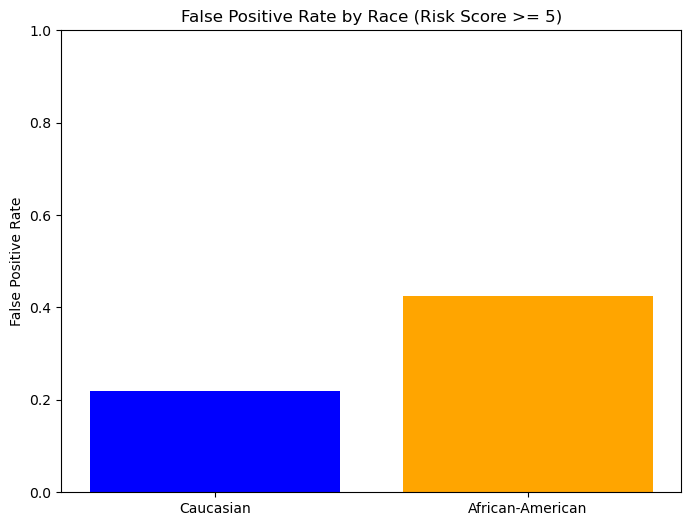

In [14]:
# Visualization
groups = ['Caucasian', 'African-American']
fprs = [fpr_priv_manual, fpr_unpriv_manual]

plt.figure(figsize=(8, 6))
plt.bar(groups, fprs, color=['blue', 'orange'])
plt.title('False Positive Rate by Race (Risk Score >= 5)')
plt.ylabel('False Positive Rate')
plt.ylim(0, 1)
plt.show()